In [1]:
import matplotlib.pyplot as plt
import pickle
import numpy as np

In [2]:
# Load the entire datasets dictionary
with open('era5_datasets.pkl', 'rb') as f:
    loaded_data = pickle.load(f)

# Now you can access your original variables
rain_rate = loaded_data['rain_rate']
time_era = loaded_data['time']
R_era = loaded_data['R']
Z_t_era = loaded_data['Z_t']
Z_t_new_era = loaded_data['Z_t_new']
metadata_era = loaded_data['metadata']

c:\Users\chari\miniconda3\envs\mude\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [3]:
with open('radiometer_datasets.pkl', 'rb') as f:
    loaded_data = pickle.load(f)

# Now you can access your original variables
rain_rate = loaded_data['rain_rate']
time_mwr = loaded_data['time']
R_mwr = loaded_data['R']
Z_t_mwr = loaded_data['Z_t']
Z_t_new_mwr = loaded_data['Z_t_new']
metadata_radiometer = loaded_data['metadata']

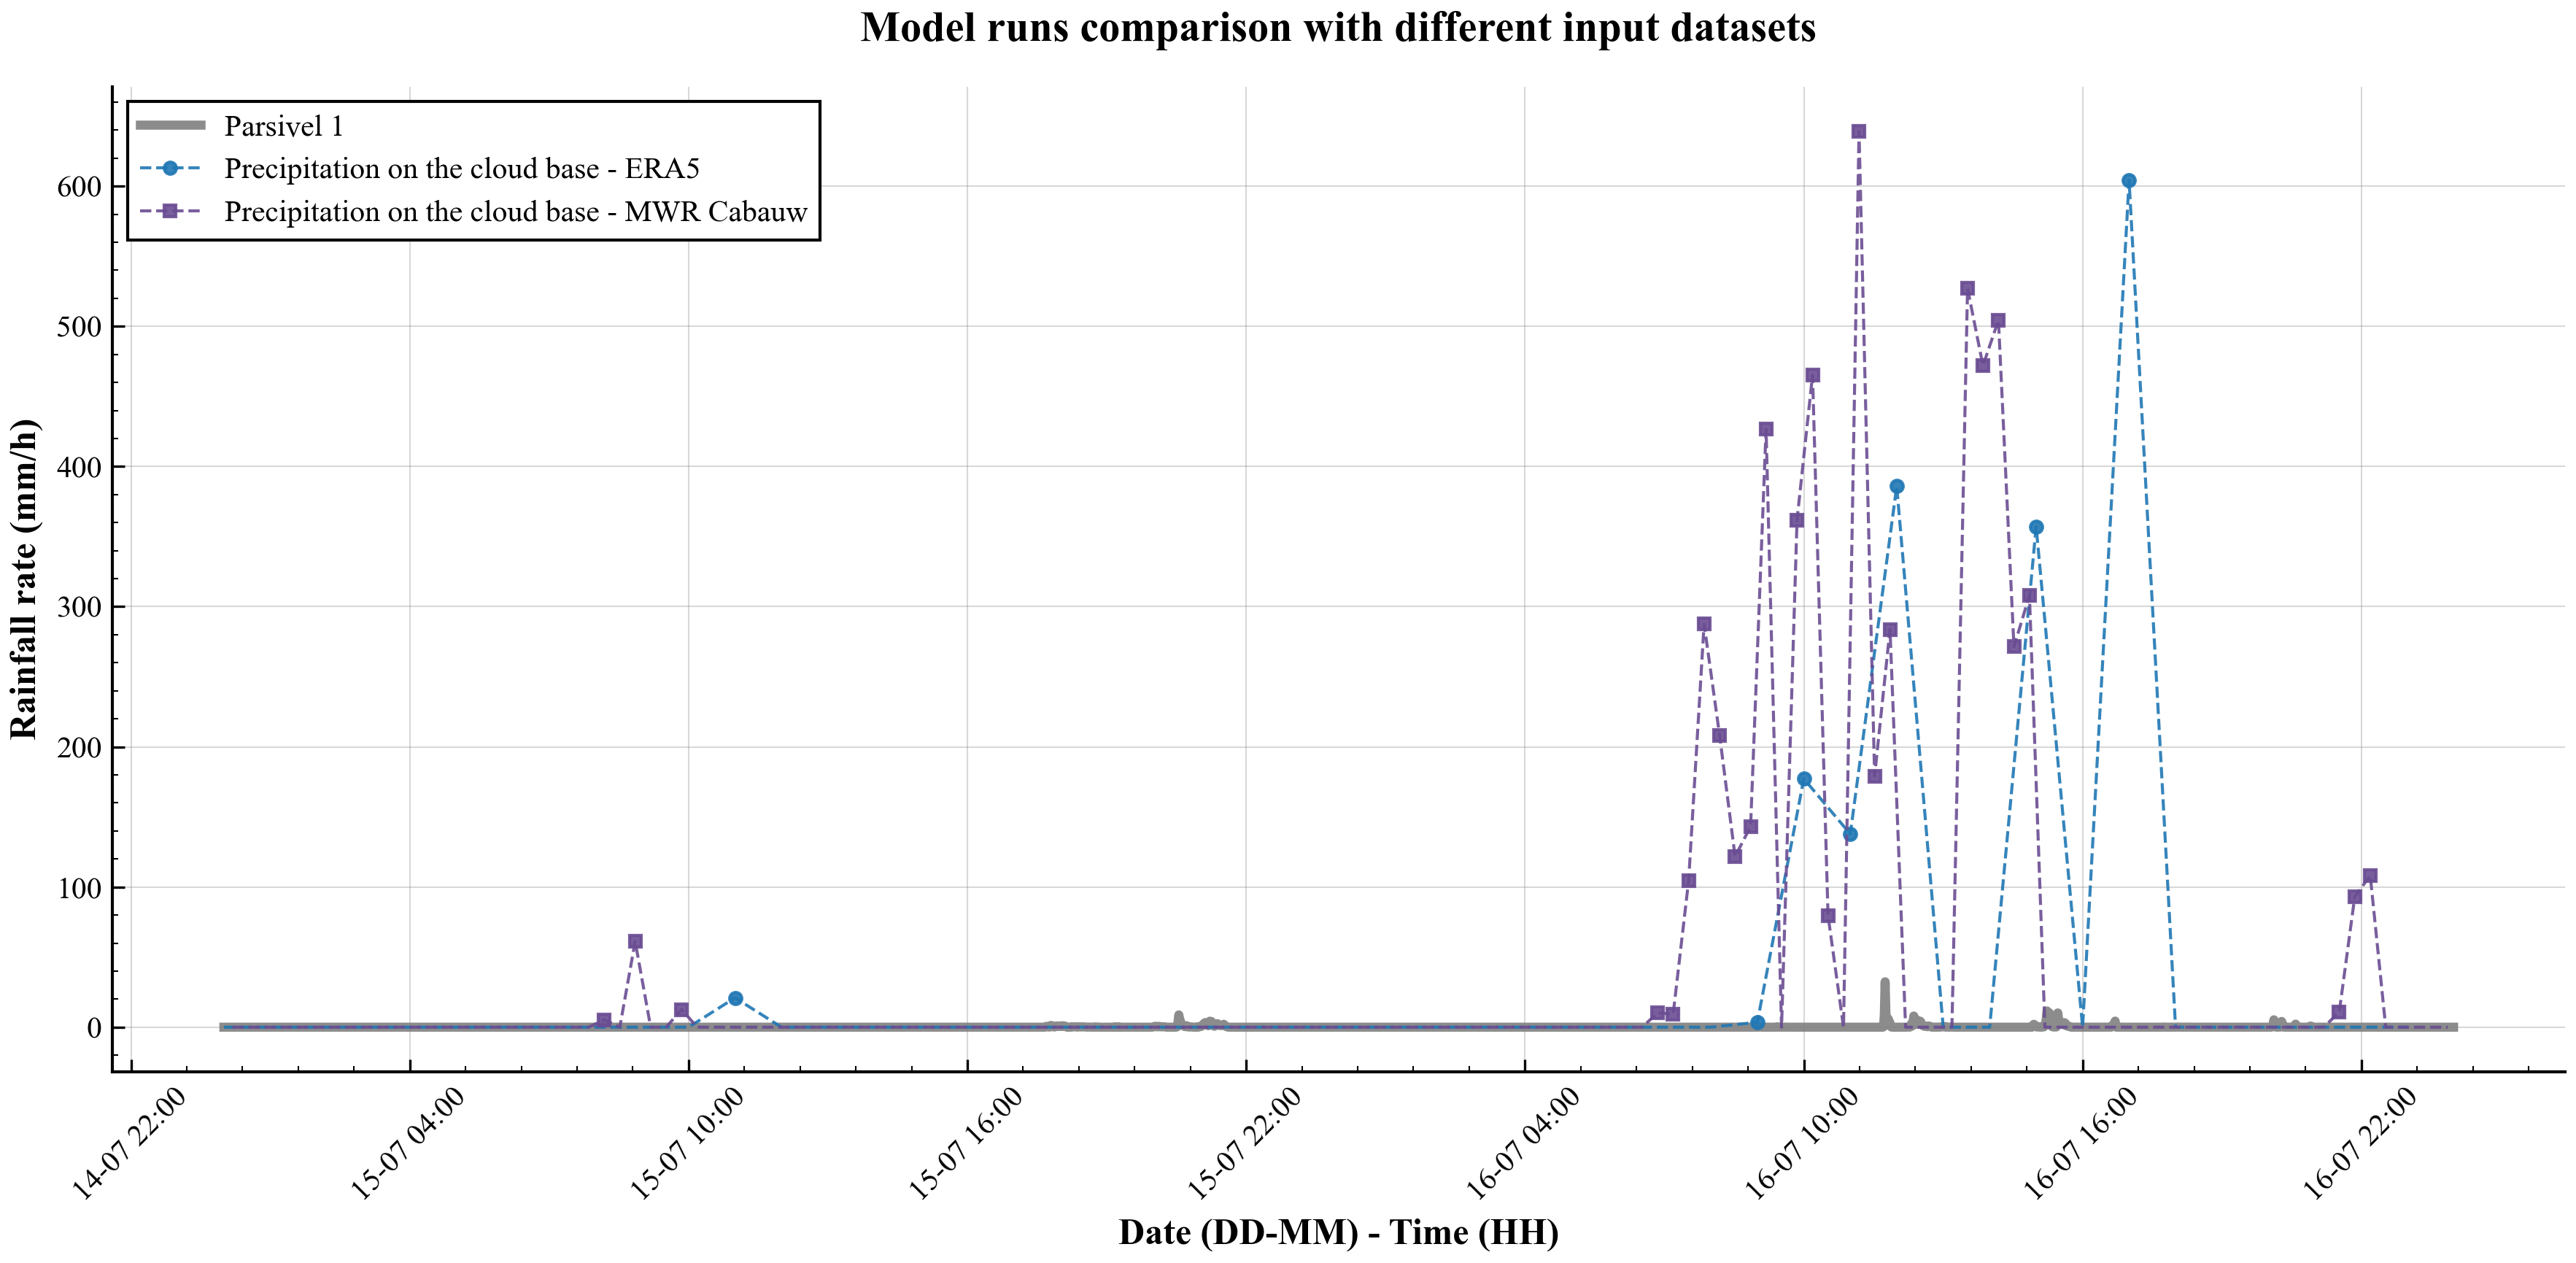

In [4]:
# SCALE FACTOR - Change this to scale the entire plot
SCALE_FACTOR = 1.0  # 1.0 = original size, 0.5 = half size, 0.25 = quarter size, etc.

# Scientific publication-quality styling - scaled by SCALE_FACTOR
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings for scientific publications - scaled by SCALE_FACTOR
    'font.size': 11 * SCALE_FACTOR,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',  # Computer Modern for math
    'text.usetex': False,  # Set to True if LaTeX is available
    
    # Axes and lines - scaled by SCALE_FACTOR
    'axes.linewidth': 1.0 * SCALE_FACTOR,
    'axes.labelsize': 12 * SCALE_FACTOR,
    'axes.titlesize': 14 * SCALE_FACTOR,
    'axes.labelweight': 'normal',
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    
    # Ticks - scaled by SCALE_FACTOR
    'xtick.labelsize': 10 * SCALE_FACTOR,
    'ytick.labelsize': 10 * SCALE_FACTOR,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 4 * SCALE_FACTOR,
    'xtick.minor.size': 2 * SCALE_FACTOR,
    'ytick.major.size': 4 * SCALE_FACTOR,
    'ytick.minor.size': 2 * SCALE_FACTOR,
    'xtick.major.width': 0.8 * SCALE_FACTOR,
    'xtick.minor.width': 0.5 * SCALE_FACTOR,
    'ytick.major.width': 0.8 * SCALE_FACTOR,
    'ytick.minor.width': 0.5 * SCALE_FACTOR,
    
    # Legend - scaled by SCALE_FACTOR
    'legend.fontsize': 10 * SCALE_FACTOR,
    'legend.framealpha': 1.0,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    
    # Figure quality - keep DPI high for quality
    'figure.dpi': 300,
    'savefig.dpi': 600,  # Higher DPI for publication
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05 * SCALE_FACTOR,
    'savefig.format': 'pdf',  # Vector format preferred
})

# Create figure - scaled by SCALE_FACTOR
fig, ax = plt.subplots(figsize=(12 * SCALE_FACTOR, 6 * SCALE_FACTOR))

# Scientific color palette (colorblind-friendly)
colors = {
    'parsivel': '#808080',     # Grey
    'model ERA5': '#1f77b4',       # Blue
    'model MWR': '#6A4C93',      # Nice scientific purple
}

# Plot with scientific line styles and markers - scaled line widths by SCALE_FACTOR
#plt.plot(time,P*3600,label='Precipitation on the ground',color='blue')
line_parsivel = ax.plot(rain_rate.time, rain_rate, 
                       color=colors['parsivel'], 
                       label='Parsivel 1',
                       linewidth=3 * SCALE_FACTOR,
                       alpha=0.9)

era_nonzero_indices = np.where(R_era * 3600 > 0)[0]  # Get indices where values > 0

line_model_era = ax.plot(time_era, R_era * 3600,
                        color=colors['model ERA5'],
                        linestyle='--',
                        label='Precipitation on the cloud base - ERA5',
                        linewidth=1.0 * SCALE_FACTOR,
                        marker='o',
                        markersize=4 * SCALE_FACTOR,
                        markevery=era_nonzero_indices,  # Only show markers at these indices
                        alpha=0.9)

# For MWR - markers only where values > 0  
mwr_nonzero_indices = np.where(R_mwr * 3600 > 0)[0]  # Get indices where values > 0

line_model_mwr = ax.plot(time_mwr, R_mwr * 3600,
                        color=colors['model MWR'],
                        linestyle='--',
                        label='Precipitation on the cloud base - MWR Cabauw',
                        linewidth=1.0 * SCALE_FACTOR,
                        marker='s',
                        markersize=4 * SCALE_FACTOR,
                        markevery=mwr_nonzero_indices,  # Only show markers at these indices
                        alpha=0.9)
#plt.plot(time,R_old*3600,color='red',linestyle='--',label='Precipitation on the ground - model')
#plt.plot(rain_rate.time[indexes_strat],rain_rate[indexes_strat],color='gray',label='Stratiform event')

# Scientific axis labels with units
ax.set_xlabel('Date (DD-MM) - Time (HH)', fontweight='bold')
ax.set_ylabel('Rainfall rate (mm/h)', fontweight='bold')
ax.set_title('Model runs comparison with different input datasets', fontweight='bold', pad=15 * SCALE_FACTOR)

# Scientific grid - scaled by SCALE_FACTOR
ax.grid(True, alpha=0.3, linewidth=0.5 * SCALE_FACTOR, color='gray')
ax.set_axisbelow(True)

# Minor ticks for precision
ax.minorticks_on()

# Scientific legend positioning - scaled by SCALE_FACTOR
legend = ax.legend(loc='upper left',
                  frameon=True,
                  framealpha=1.0,
                  edgecolor='black',
                  facecolor='white',
                  borderaxespad=0.5 * SCALE_FACTOR,
                  ncol=1)

# Professional tick formatting
# Only apply scalar formatting to y-axis (rainfall rate)
ax.ticklabel_format(style='plain', axis='y')

# Ensure scientific notation if needed for y-axis only
from matplotlib.ticker import ScalarFormatter
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))

# For time axis, use proper date formatting - scale-aware
import matplotlib.dates as mdates

# Adaptive tick spacing based on scale factor
if SCALE_FACTOR >= 1.0:
    tick_interval = 6  # Every 6 hours for full size
    date_format = '%d-%m %H:%M'  # Changed to d-m format
    rotation = 45
elif SCALE_FACTOR >= 0.5:
    tick_interval = 12  # Every 12 hours for medium size
    date_format = '%d-%m %H:%M'  # Changed to d-m format
    rotation = 60
else:
    tick_interval = 24  # Daily for small size
    date_format = '%d-%m'  # Changed to d-m format for very small plots
    rotation = 45

ax.xaxis.set_major_formatter(mdates.DateFormatter(date_format))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=tick_interval))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=rotation, fontsize=10*SCALE_FACTOR)

# Tight layout for proper spacing
plt.tight_layout()

# Show the plot
plt.show()

# Reset all rcParams to matplotlib defaults
plt.rcParams.update(plt.rcParamsDefault)

In [5]:
import pandas as pd

# Create a DataFrame
df_mwr = pd.DataFrame({
    'time': time_mwr,
    'rainfall': R_mwr * 3600
})

# Set time as index and resample to hourly averages
df_mwr.set_index('time', inplace=True)
df_mwr_hourly = df_mwr.resample('H').mean()

# Extract the averaged data
time_mwr_hourly = df_mwr_hourly.index
R_mwr_hourly = df_mwr_hourly['rainfall'].values

C:\Users\chari\AppData\Local\Temp\ipykernel_44436\1228236819.py:11: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_mwr_hourly = df_mwr.resample('H').mean()


In [6]:
R_mwr_hourly

array([  0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
        22.18596916,   4.21496438,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,          nan,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   3.42922615, 133.77534253,
       157.76271193, 262.81887402, 181.67870631, 367.40751245,
         0.        , 333.00025022, 361.30151531,   0.        ,
                nan,          nan,   0.        ,   0.        ,
         0.        ,  34.63006338,  36.06340345,   0.        ])

In [7]:
import pandas as pd
import numpy as np

# Convert to pandas datetime for easier analysis
time_mwr_dt = pd.to_datetime(time_mwr)

# Create expected continuous time sequence
start_time = time_mwr_dt.min()
end_time = time_mwr_dt.max()

# Determine frequency from the data
time_diff = pd.Series(time_mwr_dt).diff().mode()[0]  # Most common difference
print(f"Most common time difference: {time_diff}")

# Create expected full range
expected_times = pd.date_range(start=start_time, end=end_time, freq=time_diff)
actual_times = pd.Series(time_mwr_dt)

print(f"Expected time points: {len(expected_times)}")
print(f"Actual time points: {len(actual_times)}")
print(f"Missing time points: {len(expected_times) - len(actual_times)}")

# Find missing times
missing_times = expected_times.difference(actual_times)
if len(missing_times) > 0:
    print(f"\nFirst 10 missing timestamps:")
    print(missing_times[:10])

Most common time difference: 0 days 00:20:00.036621094
Expected time points: 144
Actual time points: 135
Missing time points: 9

First 10 missing timestamps:
DatetimeIndex(['2024-07-15 00:31:02.072753906',
                  '2024-07-15 00:51:02.109375',
               '2024-07-15 01:11:02.145996094',
               '2024-07-15 01:31:02.182617188',
               '2024-07-15 01:51:02.219238282',
               '2024-07-15 02:11:02.255859376',
               '2024-07-15 02:31:02.292480470',
               '2024-07-15 02:51:02.329101564',
               '2024-07-15 03:11:02.365722658',
               '2024-07-15 03:31:02.402343752'],
              dtype='datetime64[ns]', freq='1200036621094ns')


In [8]:
import pandas as pd
import numpy as np

# Step 1: Create DataFrame with datetime index
df_mwr = pd.DataFrame({
    'rainfall': R_mwr * 3600  # Convert to mm/h and put in DataFrame
}, index=pd.to_datetime(time_mwr))  # Use time as the index

# Step 2: Resample to hourly averages
df_mwr_hourly = df_mwr.resample('H').mean()
# This groups data by hour and calculates the mean for each hour
# If an hour has no data or only NaN values, the result will be NaN

# Step 3: Handle the NaNs
df_mwr_hourly = df_mwr_hourly.fillna(0)  
# This replaces all NaN values with 0
# The logic: if there's no precipitation data for an hour, assume 0 rainfall

# Step 4: Extract the clean data for plotting
time_mwr_hourly = df_mwr_hourly.index      # Hourly timestamps
R_mwr_hourly = df_mwr_hourly['rainfall'].values  # Rainfall values as numpy array

# Step 5: Verification
print(f"Final hourly data points: {len(R_mwr_hourly)}")
print(f"Remaining NaNs: {np.sum(np.isnan(R_mwr_hourly))}")

Final hourly data points: 48
Remaining NaNs: 0


C:\Users\chari\AppData\Local\Temp\ipykernel_44436\127263123.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_mwr_hourly = df_mwr.resample('H').mean()


In [9]:
hourly_avg = rain_rate.resample(time='1H').mean()

c:\Users\chari\miniconda3\envs\mude\Lib\site-packages\xarray\groupers.py:490: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(


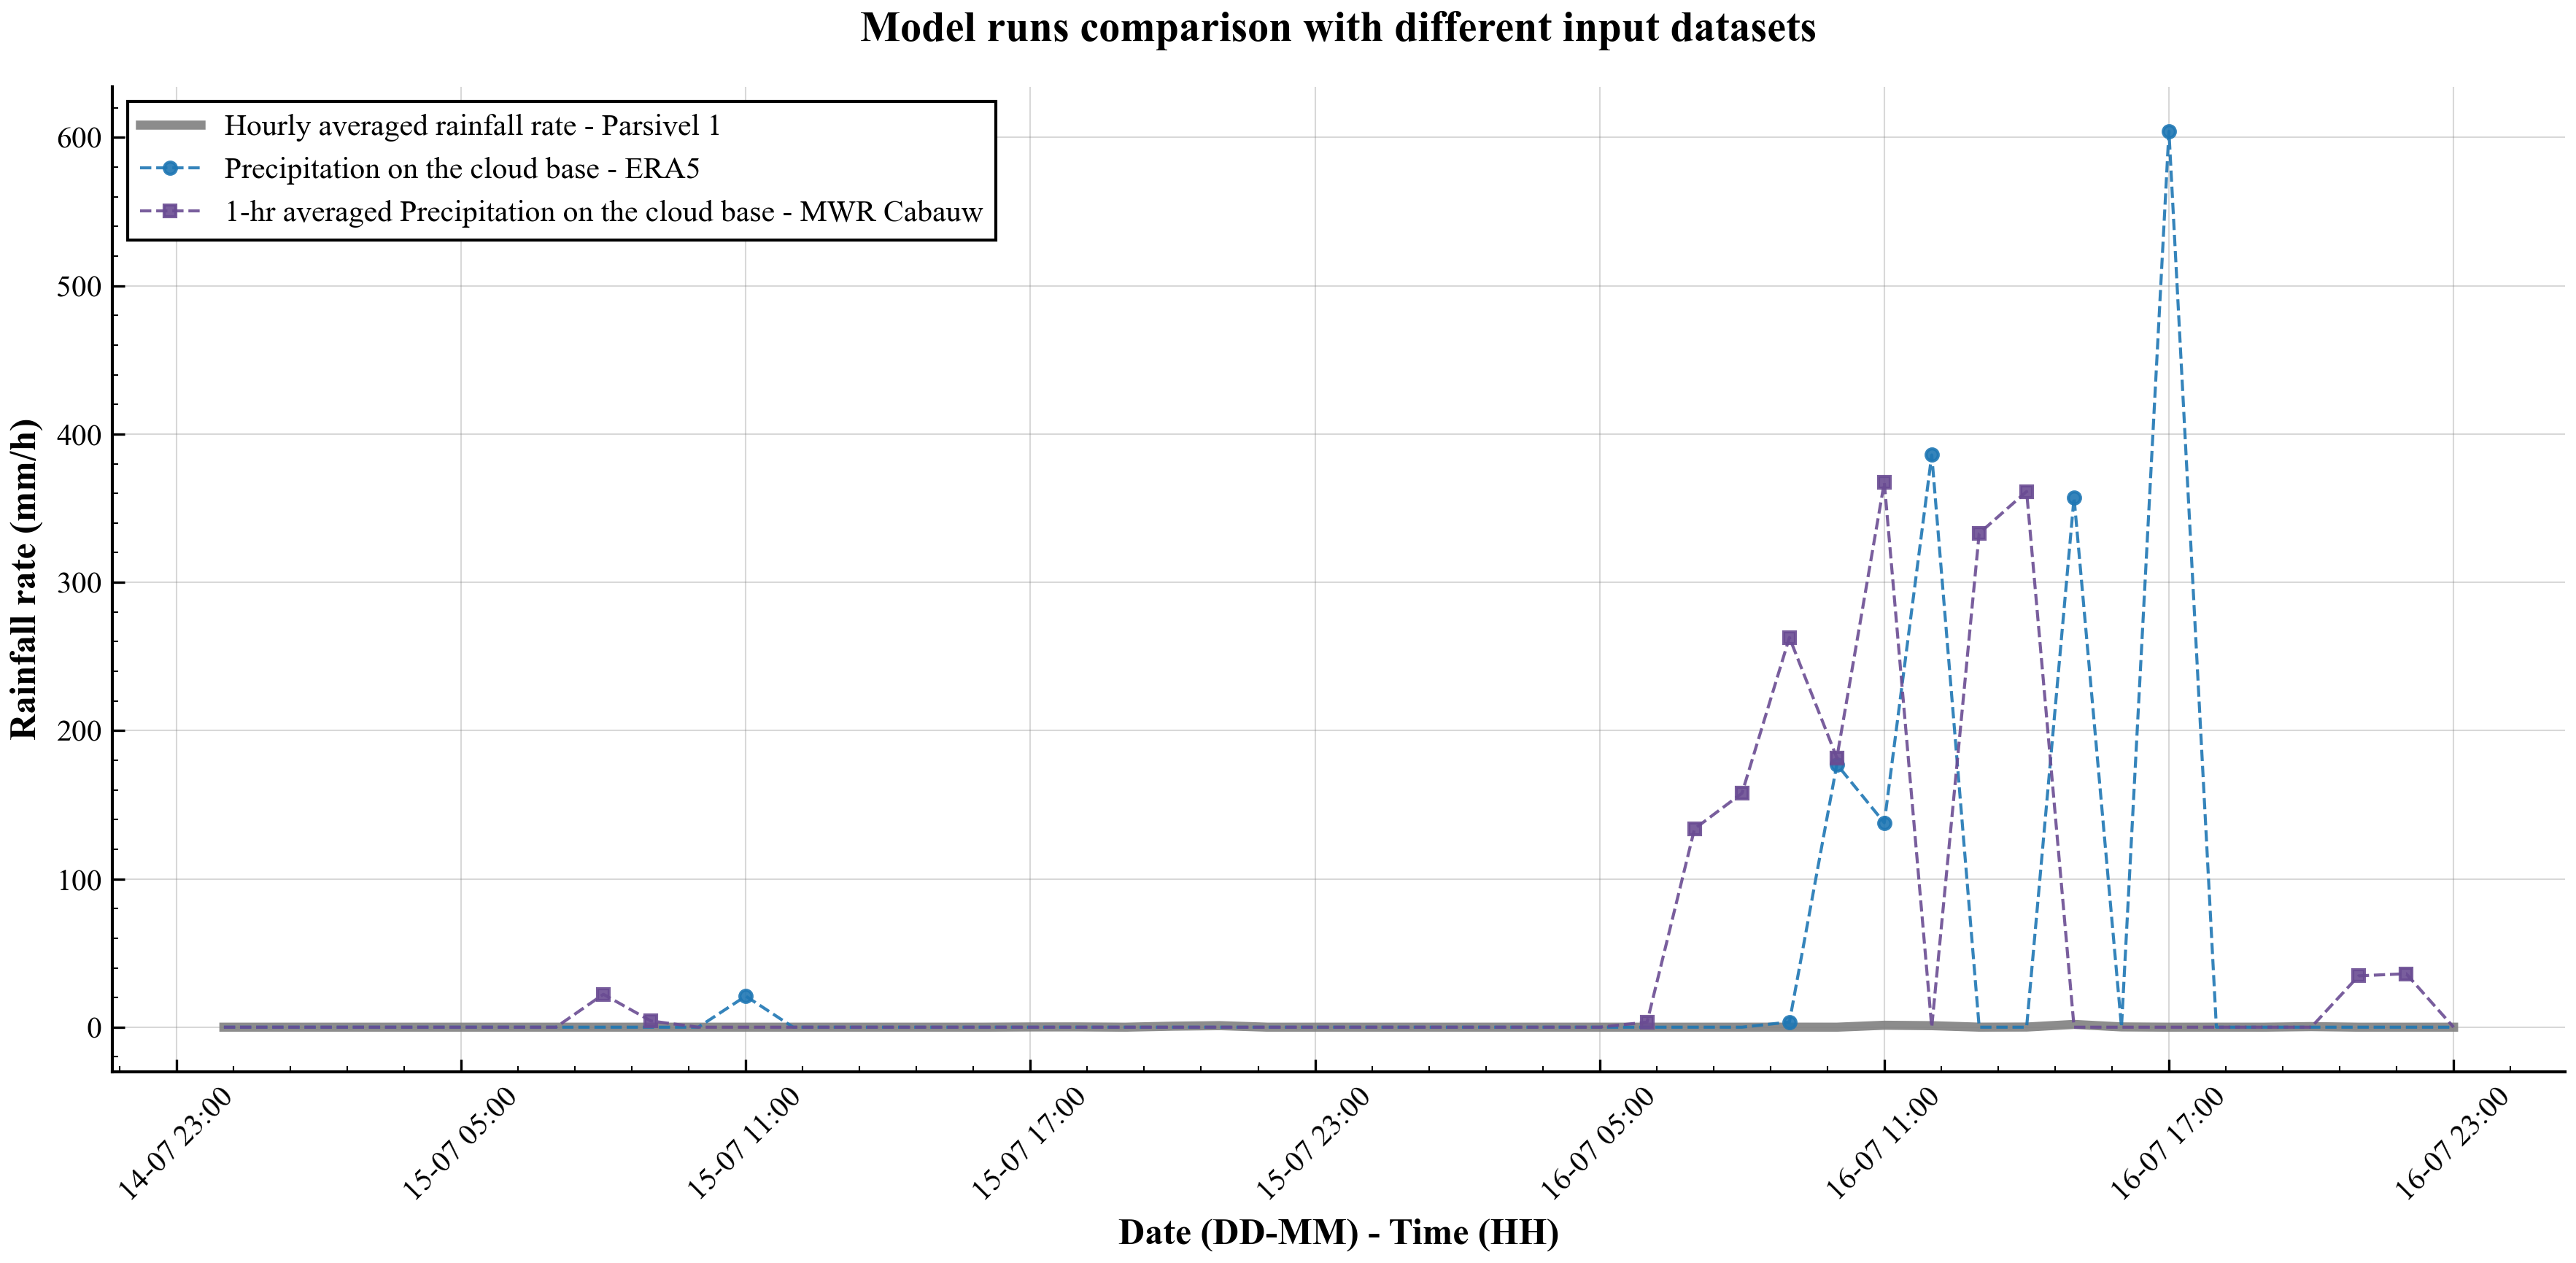

In [10]:
# SCALE FACTOR - Change this to scale the entire plot
SCALE_FACTOR = 1.0  # 1.0 = original size, 0.5 = half size, 0.25 = quarter size, etc.

# Scientific publication-quality styling - scaled by SCALE_FACTOR
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings for scientific publications - scaled by SCALE_FACTOR
    'font.size': 11 * SCALE_FACTOR,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',  # Computer Modern for math
    'text.usetex': False,  # Set to True if LaTeX is available
    
    # Axes and lines - scaled by SCALE_FACTOR
    'axes.linewidth': 1.0 * SCALE_FACTOR,
    'axes.labelsize': 12 * SCALE_FACTOR,
    'axes.titlesize': 14 * SCALE_FACTOR,
    'axes.labelweight': 'normal',
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    
    # Ticks - scaled by SCALE_FACTOR
    'xtick.labelsize': 10 * SCALE_FACTOR,
    'ytick.labelsize': 10 * SCALE_FACTOR,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 4 * SCALE_FACTOR,
    'xtick.minor.size': 2 * SCALE_FACTOR,
    'ytick.major.size': 4 * SCALE_FACTOR,
    'ytick.minor.size': 2 * SCALE_FACTOR,
    'xtick.major.width': 0.8 * SCALE_FACTOR,
    'xtick.minor.width': 0.5 * SCALE_FACTOR,
    'ytick.major.width': 0.8 * SCALE_FACTOR,
    'ytick.minor.width': 0.5 * SCALE_FACTOR,
    
    # Legend - scaled by SCALE_FACTOR
    'legend.fontsize': 10 * SCALE_FACTOR,
    'legend.framealpha': 1.0,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    
    # Figure quality - keep DPI high for quality
    'figure.dpi': 300,
    'savefig.dpi': 600,  # Higher DPI for publication
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05 * SCALE_FACTOR,
    'savefig.format': 'pdf',  # Vector format preferred
})

# Create figure - scaled by SCALE_FACTOR
fig, ax = plt.subplots(figsize=(12 * SCALE_FACTOR, 6 * SCALE_FACTOR))

# Scientific color palette (colorblind-friendly)
colors = {
    'parsivel': '#808080',     # Grey
    'model ERA5': '#1f77b4',       # Blue
    'model MWR': '#6A4C93',      # Nice scientific purple
}

# Plot with scientific line styles and markers - scaled line widths by SCALE_FACTOR
#plt.plot(time,P*3600,label='Precipitation on the ground',color='blue')
line_parsivel = ax.plot(time_era, hourly_avg, 
                       color=colors['parsivel'], 
                       label='Hourly averaged rainfall rate - Parsivel 1',
                       linewidth=3 * SCALE_FACTOR,
                       alpha=0.9)

era_nonzero_indices = np.where(R_era * 3600 > 0)[0]  # Get indices where values > 0

line_model_era = ax.plot(time_era, R_era * 3600,
                        color=colors['model ERA5'],
                        linestyle='--',
                        label='Precipitation on the cloud base - ERA5',
                        linewidth=1.0 * SCALE_FACTOR,
                        marker='o',
                        markersize=4 * SCALE_FACTOR,
                        markevery=era_nonzero_indices,  # Only show markers at these indices
                        alpha=0.9)

# For MWR - markers only where values > 0  
mwr_nonzero_indices = np.where(R_mwr_hourly> 0)[0]  # Get indices where values > 0

line_model_mwr = ax.plot(time_era, R_mwr_hourly,
                        color=colors['model MWR'],
                        linestyle='--',
                        label='1-hr averaged Precipitation on the cloud base - MWR Cabauw',
                        linewidth=1.0 * SCALE_FACTOR,
                        marker='s',
                        markersize=4 * SCALE_FACTOR,
                        markevery=mwr_nonzero_indices,  # Only show markers at these indices
                        alpha=0.9)
#plt.plot(time,R_old*3600,color='red',linestyle='--',label='Precipitation on the ground - model')
#plt.plot(rain_rate.time[indexes_strat],rain_rate[indexes_strat],color='gray',label='Stratiform event')

# Scientific axis labels with units
ax.set_xlabel('Date (DD-MM) - Time (HH)', fontweight='bold')
ax.set_ylabel('Rainfall rate (mm/h)', fontweight='bold')
ax.set_title('Model runs comparison with different input datasets', fontweight='bold', pad=15 * SCALE_FACTOR)

# Scientific grid - scaled by SCALE_FACTOR
ax.grid(True, alpha=0.3, linewidth=0.5 * SCALE_FACTOR, color='gray')
ax.set_axisbelow(True)

# Minor ticks for precision
ax.minorticks_on()

# Scientific legend positioning - scaled by SCALE_FACTOR
legend = ax.legend(loc='upper left',
                  frameon=True,
                  framealpha=1.0,
                  edgecolor='black',
                  facecolor='white',
                  borderaxespad=0.5 * SCALE_FACTOR,
                  ncol=1)

# Professional tick formatting
# Only apply scalar formatting to y-axis (rainfall rate)
ax.ticklabel_format(style='plain', axis='y')

# Ensure scientific notation if needed for y-axis only
from matplotlib.ticker import ScalarFormatter
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))

# For time axis, use proper date formatting - scale-aware
import matplotlib.dates as mdates

# Adaptive tick spacing based on scale factor
if SCALE_FACTOR >= 1.0:
    tick_interval = 6  # Every 6 hours for full size
    date_format = '%d-%m %H:%M'  # Changed to d-m format
    rotation = 45
elif SCALE_FACTOR >= 0.5:
    tick_interval = 12  # Every 12 hours for medium size
    date_format = '%d-%m %H:%M'  # Changed to d-m format
    rotation = 60
else:
    tick_interval = 24  # Daily for small size
    date_format = '%d-%m'  # Changed to d-m format for very small plots
    rotation = 45

ax.xaxis.set_major_formatter(mdates.DateFormatter(date_format))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=tick_interval))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=rotation, fontsize=10*SCALE_FACTOR)

# Tight layout for proper spacing
plt.tight_layout()

# Show the plot
plt.show()

# Reset all rcParams to matplotlib defaults
plt.rcParams.update(plt.rcParamsDefault)

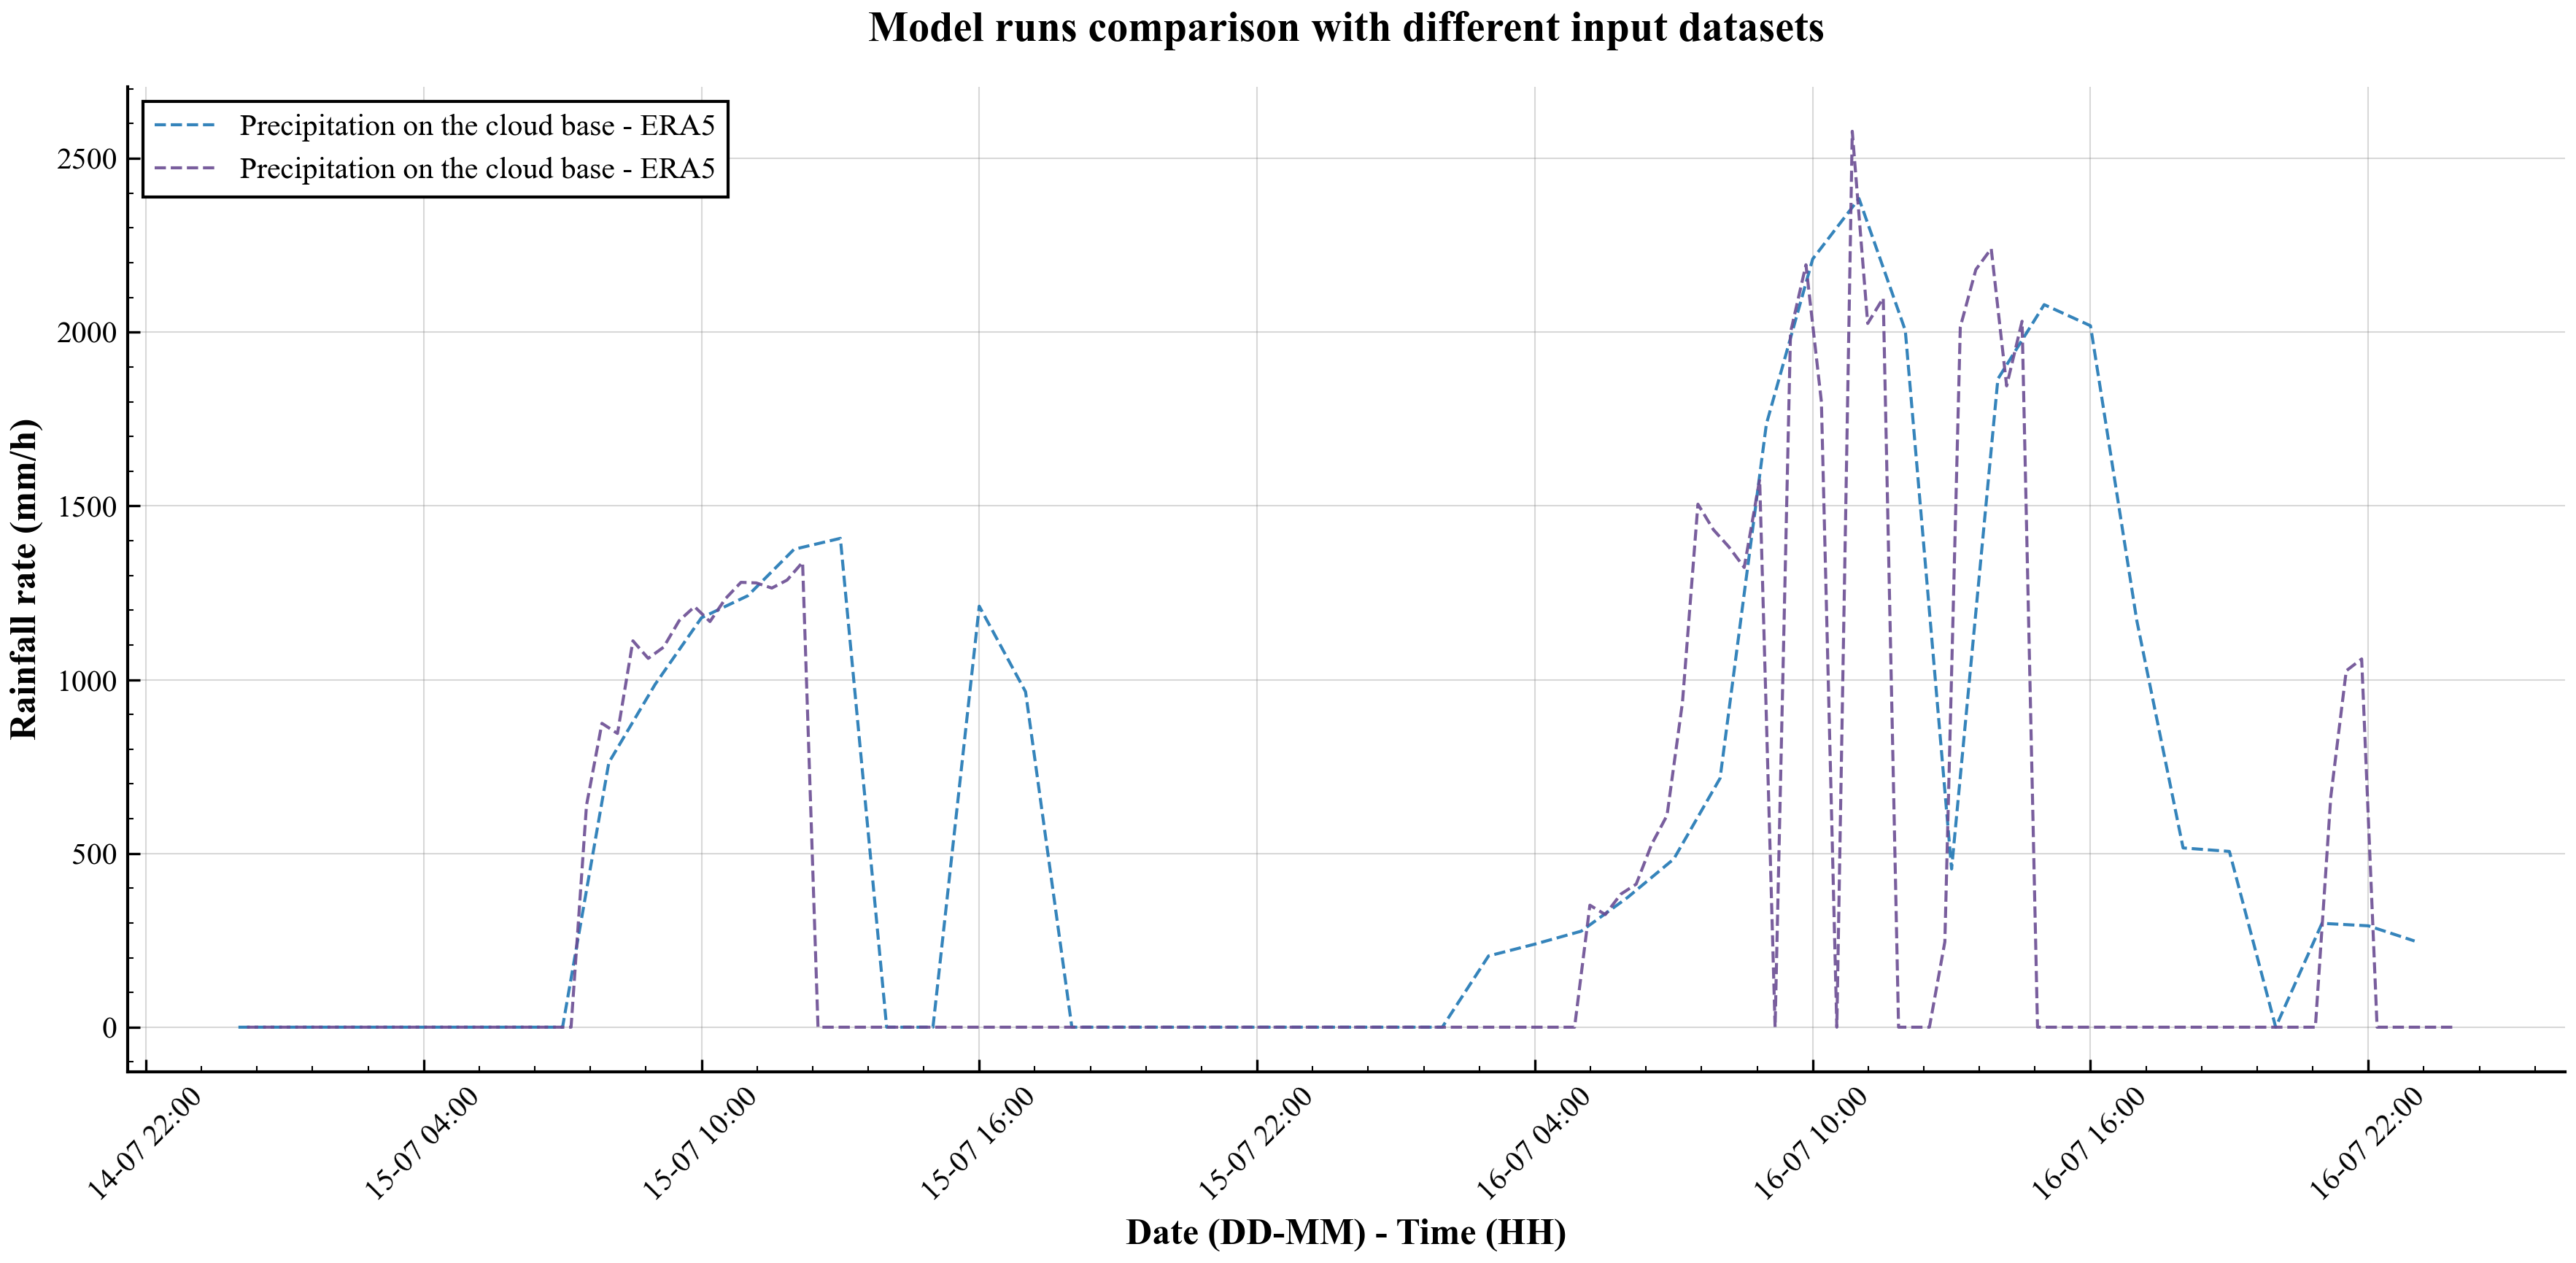

In [16]:
# SCALE FACTOR - Change this to scale the entire plot
SCALE_FACTOR = 1.0  # 1.0 = original size, 0.5 = half size, 0.25 = quarter size, etc.

# Scientific publication-quality styling - scaled by SCALE_FACTOR
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings for scientific publications - scaled by SCALE_FACTOR
    'font.size': 11 * SCALE_FACTOR,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',  # Computer Modern for math
    'text.usetex': False,  # Set to True if LaTeX is available
    
    # Axes and lines - scaled by SCALE_FACTOR
    'axes.linewidth': 1.0 * SCALE_FACTOR,
    'axes.labelsize': 12 * SCALE_FACTOR,
    'axes.titlesize': 14 * SCALE_FACTOR,
    'axes.labelweight': 'normal',
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    
    # Ticks - scaled by SCALE_FACTOR
    'xtick.labelsize': 10 * SCALE_FACTOR,
    'ytick.labelsize': 10 * SCALE_FACTOR,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 4 * SCALE_FACTOR,
    'xtick.minor.size': 2 * SCALE_FACTOR,
    'ytick.major.size': 4 * SCALE_FACTOR,
    'ytick.minor.size': 2 * SCALE_FACTOR,
    'xtick.major.width': 0.8 * SCALE_FACTOR,
    'xtick.minor.width': 0.5 * SCALE_FACTOR,
    'ytick.major.width': 0.8 * SCALE_FACTOR,
    'ytick.minor.width': 0.5 * SCALE_FACTOR,
    
    # Legend - scaled by SCALE_FACTOR
    'legend.fontsize': 10 * SCALE_FACTOR,
    'legend.framealpha': 1.0,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    
    # Figure quality - keep DPI high for quality
    'figure.dpi': 300,
    'savefig.dpi': 600,  # Higher DPI for publication
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05 * SCALE_FACTOR,
    'savefig.format': 'pdf',  # Vector format preferred
})

# Create figure - scaled by SCALE_FACTOR
fig, ax = plt.subplots(figsize=(12 * SCALE_FACTOR, 6 * SCALE_FACTOR))

# Scientific color palette (colorblind-friendly)
colors = {     # Grey
    'model ERA5': '#1f77b4',       # Blue
    'model MWR': '#6A4C93',      # Nice scientific purple
}

# Plot with scientific line styles and markers - scaled line widths by SCALE_FACTOR
#plt.plot(time,P*3600,label='Precipitation on the ground',color='blue')
"""
line_model_era = ax.plot(time_era, Z_t_era, 
                       color=colors['model ERA5'], 
                       label='Parsivel 1',
                       linewidth=1.0 * SCALE_FACTOR,
                       alpha=0.9)
"""
line_model_era_new = ax.plot(time_era, Z_t_new_era,
                        color=colors['model ERA5'],
                        linestyle='--',
                        label='Precipitation on the cloud base - ERA5',
                        linewidth=1.0 * SCALE_FACTOR,
                        alpha=0.9)

# For MWR - markers only where values > 0  
"""
line_model_mwr = ax.plot(time_mwr, Z_t_mwr, 
                       color=colors['model MWR'], 
                       label='Parsivel 1',
                       linewidth=1.0 * SCALE_FACTOR,
                       alpha=0.9)
"""
line_model_mwr_new = ax.plot(time_mwr, Z_t_new_mwr,
                        color=colors['model MWR'],
                        linestyle='--',
                        label='Precipitation on the cloud base - ERA5',
                        linewidth=1.0 * SCALE_FACTOR,
                        alpha=0.9)
#plt.plot(time,R_old*3600,color='red',linestyle='--',label='Precipitation on the ground - model')
#plt.plot(rain_rate.time[indexes_strat],rain_rate[indexes_strat],color='gray',label='Stratiform event')

# Scientific axis labels with units
ax.set_xlabel('Date (DD-MM) - Time (HH)', fontweight='bold')
ax.set_ylabel('Rainfall rate (mm/h)', fontweight='bold')
ax.set_title('Model runs comparison with different input datasets', fontweight='bold', pad=15 * SCALE_FACTOR)

# Scientific grid - scaled by SCALE_FACTOR
ax.grid(True, alpha=0.3, linewidth=0.5 * SCALE_FACTOR, color='gray')
ax.set_axisbelow(True)

# Minor ticks for precision
ax.minorticks_on()

# Scientific legend positioning - scaled by SCALE_FACTOR
legend = ax.legend(loc='upper left',
                  frameon=True,
                  framealpha=1.0,
                  edgecolor='black',
                  facecolor='white',
                  borderaxespad=0.5 * SCALE_FACTOR,
                  ncol=1)

# Professional tick formatting
# Only apply scalar formatting to y-axis (rainfall rate)
ax.ticklabel_format(style='plain', axis='y')

# Ensure scientific notation if needed for y-axis only
from matplotlib.ticker import ScalarFormatter
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))

# For time axis, use proper date formatting - scale-aware
import matplotlib.dates as mdates

# Adaptive tick spacing based on scale factor
if SCALE_FACTOR >= 1.0:
    tick_interval = 6  # Every 6 hours for full size
    date_format = '%d-%m %H:%M'  # Changed to d-m format
    rotation = 45
elif SCALE_FACTOR >= 0.5:
    tick_interval = 12  # Every 12 hours for medium size
    date_format = '%d-%m %H:%M'  # Changed to d-m format
    rotation = 60
else:
    tick_interval = 24  # Daily for small size
    date_format = '%d-%m'  # Changed to d-m format for very small plots
    rotation = 45

ax.xaxis.set_major_formatter(mdates.DateFormatter(date_format))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=tick_interval))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=rotation, fontsize=10*SCALE_FACTOR)

# Tight layout for proper spacing
plt.tight_layout()

# Show the plot
plt.show()

# Reset all rcParams to matplotlib defaults
plt.rcParams.update(plt.rcParamsDefault)

In [12]:
from scipy import stats
print(stats.pearsonr(R_era*3600, hourly_avg),stats.pearsonr(R_mwr_hourly, hourly_avg))

PearsonRResult(statistic=0.4727832793783895, pvalue=0.0006905968245727438) PearsonRResult(statistic=0.1425452347405169, pvalue=0.3337954234528494)
